# Diabetes Prediction – Exploratory Data Analysis

This notebook presents the exploratory data analysis (EDA) performed on the diabetes dataset.
The purpose of this analysis is to understand the structure of the data, identify potential
data quality issues, and explore relationships between features and the target variable
before proceeding to preprocessing and model development.

---

## Importing Required Libraries

Basic Python libraries are imported to support data handling, numerical operations,
and visual exploration throughout the analysis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_style("whitegrid")

## Loading the Dataset

The dataset is loaded using pandas to enable easy inspection and analysis
of patient records and medical attributes.


In [2]:
df=pd.read_csv("../data/Dataset/diabetes_prediction_dataset-Copy1.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## EDA STEP 1: Basic Dataset Structure Inspection
Before applying any machine learning technique, it is important to first understand the structure of the dataset. This helps in identifying the type of features present, their data types, and whether any immediate preprocessing is required.

The dataset contains patient-related medical information along with a target variable indicating whether the person has diabetes or not.

In [3]:
print(df.shape)  #no. of rows and columns 

(100000, 9)


In [4]:
print(df.info())  #data type and count including non null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


In [5]:
print(df.columns)  #column name

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


### Basic Information

- Total number of records: 100,000  
- Total number of features: 9  
- Target variable: `diabetes` (0 = Non-diabetic, 1 = Diabetic)

### Feature Types

The dataset includes both numerical and categorical features:

**Categorical Features:**
- `gender`
- `smoking_history`

These variables represent non-numeric information and will need to be converted into numerical form before model training.

**Numerical Features:**
- `age`
- `hypertension`
- `heart_disease`
- `bmi`
- `HbA1c_level`
- `blood_glucose_level`

These features represent measurable medical attributes and can be directly used for analysis.

### Initial Observations

- The dataset is relatively large, which is beneficial for training machine learning models.
- There are no obvious inconsistencies in data types.
- Presence of categorical features indicates that encoding will be required in later stages.

At this stage, the dataset appears structured and suitable for further analysis. The next step is to check for missing or invalid values that could affect model performance.

---

## EDA STEP 2: Missing Values Check
It is necessary to check missing values to ensure data completeness before applying ml algos.

In [6]:
print(df.isnull().sum())  #count the no. of missing values per column

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


There is no explicit missing values in the dataset.  
However, certain medical attributes may contain invalid values such as zero which need further analysis.  

---

## EDA STEP 3: Checking for Invalid Zero Values
Certain medical attributes such as glucose level, blood pressure, BMI,
and insulin cannot realistically have a value of zero.

In [7]:
zero_columns = ['bmi', 'HbA1c_level', 'blood_glucose_level', 'age']
(df[zero_columns] == 0).sum()

bmi                    0
HbA1c_level            0
blood_glucose_level    0
age                    0
dtype: int64

No zero values are present in features.  
The dataset is clean and does not require preprocessing at this stage.

---

## EDA STEP 4: Target Variable Analysis
Target variable ("Outcome") represents whether a patient is diabetic or not. Analyzing its distribution helps in understanding class balance, wichh plays important role in model training and evaluation.

In [8]:
df["diabetes"].value_counts(normalize=True).round(4)*100  #count unique values,convert to proportions,rounds to 4 decimal places,convert into percentage

diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64

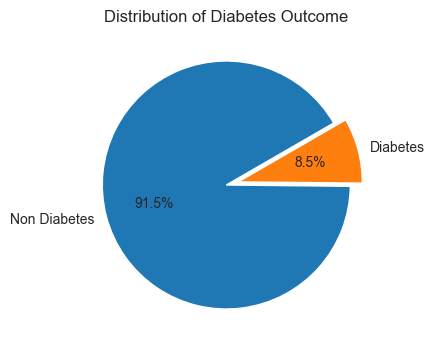

In [9]:
plt.figure(figsize=(4,6))
plt.pie(df["diabetes"].value_counts(),
        labels=["Non Diabetes","Diabetes"],
        autopct="%.1f%%",
        startangle=30,
        explode=(0,0.1))
plt.title("Distribution of Diabetes Outcome")
plt.show()

- Non-diabetic: ~91.5%
- Diabetic: ~8.5%

The dataset is highly imbalanced.

This means accuracy alone is not a reliable metric.  
Evaluation should focus on Recall and F1-score, especially for the diabetic class.

---

## EDA STEP 5: Statistical Summary
Statistical descriotions are used to understand the central tendency and
spread of numerical features in the dataset.

In [10]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


- Average age is around 42, with a wide spread across age groups.
- BMI is centered around 27, indicating many patients are in the overweight range.
- Blood glucose and HbA1c values show noticeable variation, suggesting strong potential for predicting diabetes.

Overall, numerical features have reasonable distributions without obvious anomalies.

---

## EDA STEP 6: Feature Distribution (Univariate Analysis)

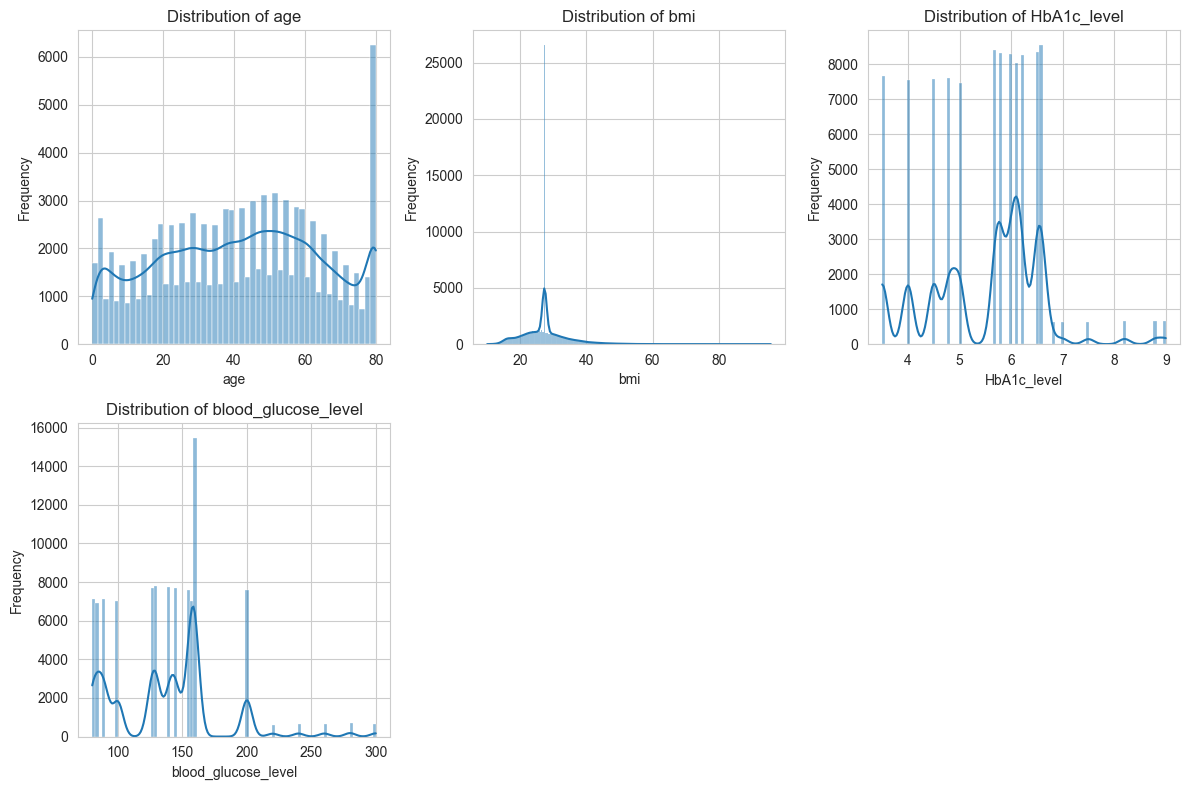

In [11]:
cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']   
n_cols = 3               
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide empty subplots
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- Age is distributed across all groups, with higher concentration in middle age.
- BMI is slightly right-skewed, with most values in the overweight range.
- HbA1c levels show clustered patterns, indicating potential separation between diabetic and non-diabetic cases.
- Blood glucose level has a wide spread with distinct peaks, suggesting strong predictive importance.

Among all features, glucose-related variables appear to carry the most useful information for prediction.

### Analysis of Histogram Plot (Outlier Analysis):

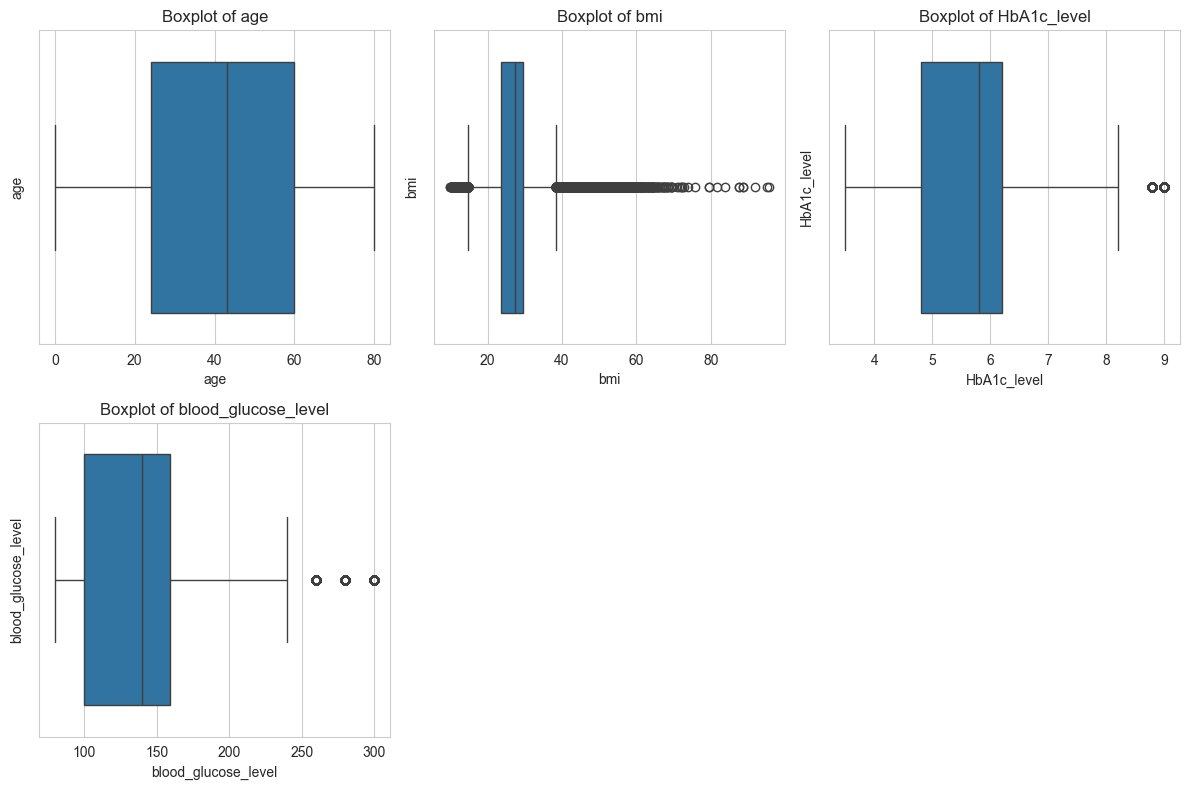

In [12]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])  #ax=axes[i] the subplots to draw
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

# Hide empty subplots

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- Age does not show significant outliers and appears well distributed.
- BMI has several high-value outliers, indicating some extreme cases.
- HbA1c values are relatively stable with a few upper-end outliers.
- Blood glucose levels show a wider spread with some extreme high values.

Since this is medical data, these outliers are likely valid observations rather than errors. Therefore, they are retained for model training.

---

## EDA STEP 7: Bivariate Analysis (Feature vs Outcome)

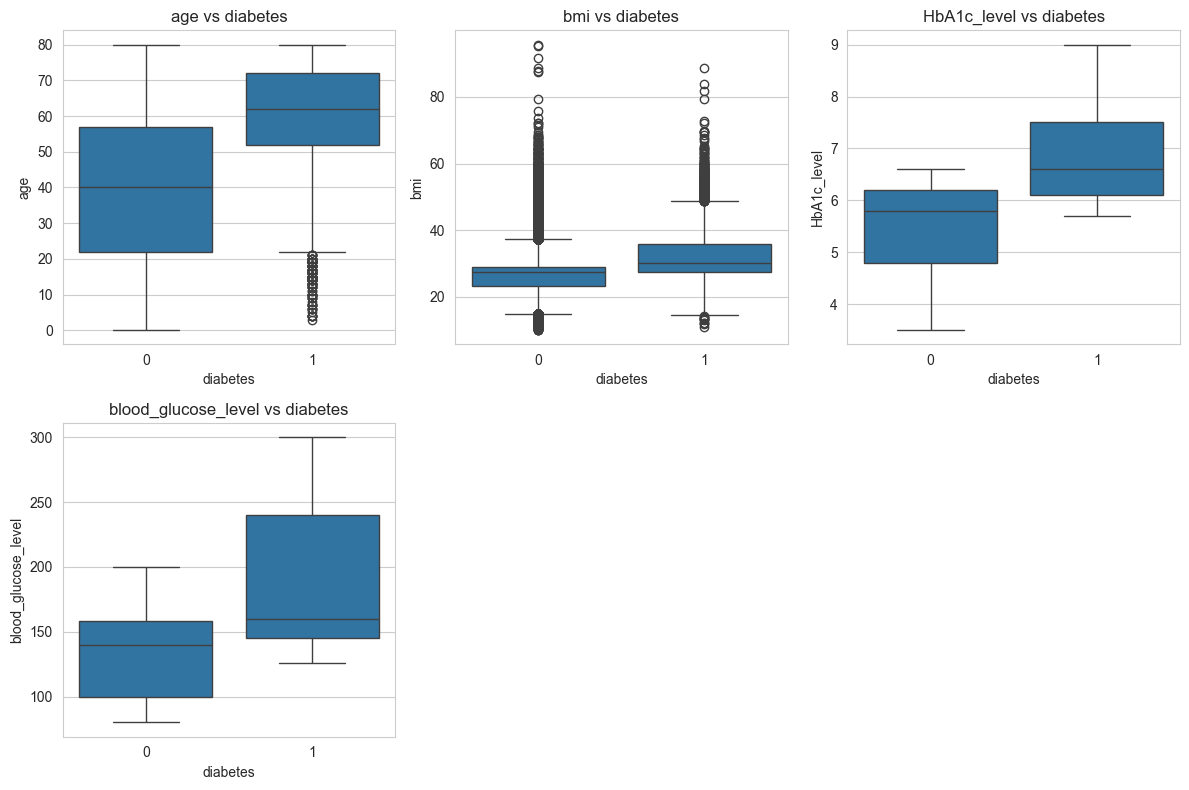

In [15]:
important_features=['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

n_cols=3
n_rows=math.ceil(len(important_features)/n_cols)

fig,axes=plt.subplots(n_rows,n_cols,figsize=(12,4*n_rows))
axes=axes.flatten()

for i,col in enumerate(important_features):
    sns.boxplot(x='diabetes', y=col, data=df,ax=axes[i])
    axes[i].set_title(f"{col} vs diabetes")
    axes[i].set_xlabel('diabetes')
    axes[i].set_ylabel(col)

for j in range(len(important_features),len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Bivariate Analysis Summary

- Blood glucose level shows a strong upward shift for diabetic patients, indicating clear separation.
- HbA1c level also shows a noticeable difference between the two classes.
- BMI shows only a slight increase in diabetic cases with significant overlap.
- Age has a mild trend but does not clearly distinguish between classes.

Overall, glucose-related features provide the strongest signal for predicting diabetes, while demographic features contribute less independently.

## EDA STEP 8: Correlation Analysis
Now we will see how features relate to each other, not just outcome.  
Correlation close to +1 or -1 between input features  
As a rough rule:  
|corr| > 0.7 → strong multicollinearity risk  

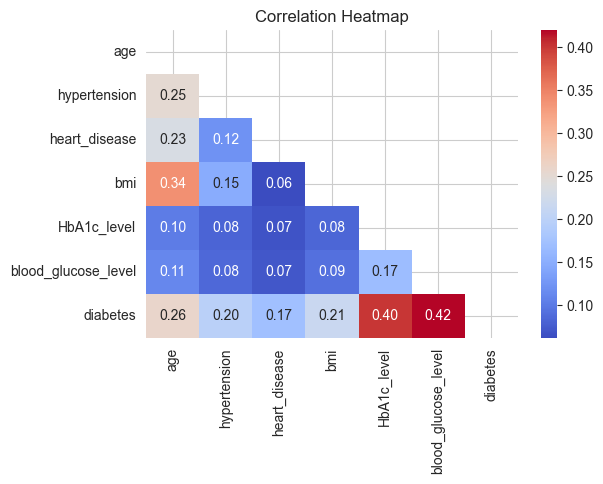

In [17]:
corr=df.corr(numeric_only=True)
mask=np.triu(np.ones_like(corr,dtype=bool))

plt.figure(figsize=(6,4))
sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis Summary

- Blood glucose level (0.42) and HbA1c level (0.40) show the strongest positive correlation with diabetes.
- Age, BMI, and hypertension have moderate correlation with the target.
- Heart disease shows relatively weaker association.

No strong correlation is observed between input features, indicating low multicollinearity.

Overall, glucose-related features are the most influential, while other features provide additional supporting information.

---

# Final EDA Conclusion

The exploratory data analysis provided key insights into the structure and characteristics of the dataset.

- The dataset is clean, with no missing or invalid values, making it suitable for direct modeling.
- A significant class imbalance is observed, with only about 8.5% diabetic cases, indicating the need for careful evaluation metrics and imbalance handling techniques.
- Glucose-related features, particularly HbA1c level and blood glucose level, show the strongest relationship with diabetes and are expected to be the most important predictors.
- BMI and age exhibit moderate influence, while features such as gender and smoking history contribute less independently.
- No strong multicollinearity is observed among input features, allowing all features to be retained for model training.

Based on these findings, the next step will involve data preprocessing, including encoding categorical variables and handling class imbalance, followed by model development.

---